# 🔍 Industrial Crack Detection Pipeline
**Goal:** Detect only **cracks** in surface images using classical computer vision.

**Pipeline:**
`Original → Grayscale → Contrast Enhancement → Denoising → Edge Detection → Thresholding → Crack Mask → Final Result`

In [3]:
# Install required libraries (run once)
# !pip install opencv-python-headless matplotlib numpy scikit-image

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import morphology, measure
from skimage.morphology import skeletonize
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 1 — Load Image
Replace `image_path` with your own image. A synthetic concrete surface with a crack is generated if no image is provided.

✅ Loaded image: /Users/macstore.uz/Week 14/image8.jpg  shape=(1024, 1536, 3)


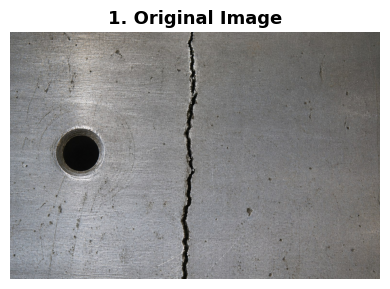

In [6]:
# ─── CONFIG ──────────────────────────────────────────────────────────
image_path = '/Users/macstore.uz/Week 14/image8.jpg'          # Set to your image path, e.g. 'surface.jpg'
                           # If None → synthetic demo image is generated
# ─────────────────────────────────────────────────────────────────────

def generate_synthetic_surface(h=400, w=300):
    """Generate a synthetic concrete-like surface with a realistic crack."""
    np.random.seed(42)
    # Base texture
    base = np.random.randint(150, 200, (h, w), dtype=np.uint8)
    base = cv2.GaussianBlur(base, (5, 5), 0)
    # Add noise texture
    noise = np.random.randint(0, 30, (h, w), dtype=np.uint8)
    surface = cv2.add(base, noise)
    # Draw a jagged crack
    x = w // 2
    for y in range(20, h - 20):
        x += np.random.randint(-2, 3)
        x = np.clip(x, 10, w - 10)
        thickness = np.random.randint(1, 3)
        cv2.line(surface, (x - thickness, y), (x + thickness, y), 20, thickness)
    # Add some dark pitting spots (NOT holes — just surface blemishes)
    for _ in range(30):
        cx, cy = np.random.randint(10, w-10), np.random.randint(10, h-10)
        cv2.circle(surface, (cx, cy), np.random.randint(1, 4), 80, -1)
    img_bgr = cv2.cvtColor(surface, cv2.COLOR_GRAY2BGR)
    return img_bgr

if image_path:
    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f'Could not load image: {image_path}')
    print(f'✅ Loaded image: {image_path}  shape={original.shape}')
else:
    original = generate_synthetic_surface()
    print('✅ Synthetic demo surface generated  shape=', original.shape)

plt.figure(figsize=(4, 5))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('1. Original Image', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Steps 2–4 — Grayscale → Contrast Enhancement → Denoising

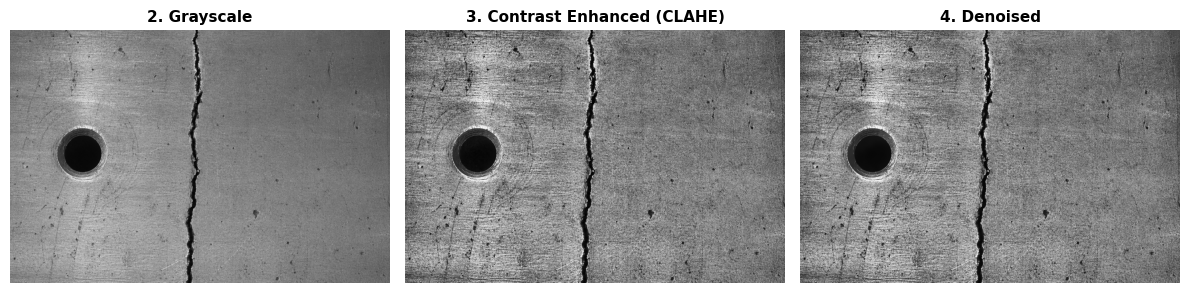

In [7]:
# 2. Grayscale
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

# 3. Contrast Enhancement — CLAHE (better than plain histogram equalization)
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
contrast = clahe.apply(gray)

# 4. Denoising — Non-local means
denoised = cv2.fastNlMeansDenoising(contrast, h=7, templateWindowSize=7, searchWindowSize=21)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ['2. Grayscale', '3. Contrast Enhanced (CLAHE)', '4. Denoised']
imgs   = [gray, contrast, denoised]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Steps 5–6 — Edge Detection → Thresholding

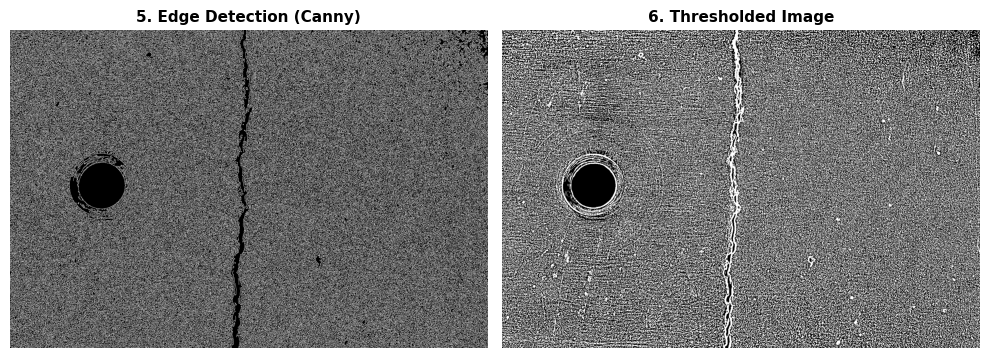

In [8]:
# 5. Canny Edge Detection
edges = cv2.Canny(denoised, threshold1=30, threshold2=100, apertureSize=3, L2gradient=True)

# 6. Adaptive Thresholding (highlights dark crack pixels against lighter background)
thresh = cv2.adaptiveThreshold(
    denoised, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=15, C=4
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(edges, cmap='gray');  axes[0].set_title('5. Edge Detection (Canny)', fontsize=11, fontweight='bold'); axes[0].axis('off')
axes[1].imshow(thresh, cmap='gray'); axes[1].set_title('6. Thresholded Image',        fontsize=11, fontweight='bold'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 7 — Crack Mask (Morphological Filtering)
We keep only **elongated, thin structures** (cracks) and discard blobs (holes, dust spots).

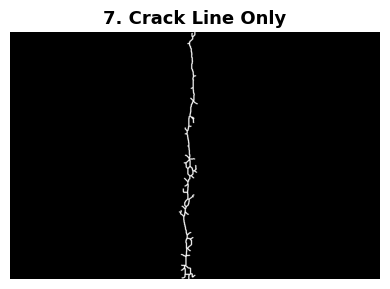

Crack line pixels detected: 9606


In [13]:
# Detect the actual crack as the longest thin dark structure.
# This avoids marking surface texture/noise and keeps the final output crack-only.
blurred = cv2.GaussianBlur(denoised, (5, 5), 0)
dark_threshold = np.percentile(blurred, 10)
dark_mask = (blurred <= dark_threshold).astype(np.uint8) * 255

# Connect the broken parts of the crack, then remove very small dots.
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 7))
dark_mask = cv2.morphologyEx(dark_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
dark_mask = morphology.remove_small_objects(dark_mask.astype(bool), min_size=80).astype(np.uint8) * 255

labels = measure.label(dark_mask > 0)
crack_mask = np.zeros_like(dark_mask, dtype=np.uint8)
height, width = dark_mask.shape
image_area = height * width

best_label = None
best_score = 0

for region in measure.regionprops(labels):
    minr, minc, maxr, maxc = region.bbox
    bbox_h = maxr - minr
    bbox_w = maxc - minc
    bbox_area = bbox_h * bbox_w

    if region.area < 80 or region.minor_axis_length == 0:
        continue

    aspect_ratio = region.major_axis_length / max(region.minor_axis_length, 1e-6)
    bbox_long_side = max(bbox_h, bbox_w)
    bbox_short_side = max(min(bbox_h, bbox_w), 1)
    bbox_ratio = bbox_long_side / bbox_short_side

    is_long_thin_dark_crack = (
        region.eccentricity > 0.92 and
        aspect_ratio > 3.0 and
        bbox_ratio > 4.0 and
        bbox_long_side > min(height, width) * 0.25 and
        bbox_area < image_area * 0.12
    )

    if is_long_thin_dark_crack:
        score = region.major_axis_length * aspect_ratio * (1.0 - min(region.solidity, 0.95))
        if score > best_score:
            best_score = score
            best_label = region.label

# If the strict detector misses, fall back to the previous edge/threshold logic.
if best_label is not None:
    crack_mask[labels == best_label] = 255
else:
    combined = cv2.bitwise_or(thresh, edges)
    closed = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=2)
    cleaned = morphology.remove_small_objects(closed.astype(bool), min_size=35).astype(np.uint8) * 255
    labels = measure.label(cleaned > 0)

    for region in measure.regionprops(labels):
        if region.area < 35 or region.minor_axis_length == 0:
            continue
        aspect_ratio = region.major_axis_length / max(region.minor_axis_length, 1e-6)
        if aspect_ratio > 3.0 and region.eccentricity > 0.90 and region.solidity < 0.90:
            crack_mask[labels == region.label] = 255

# Convert detected crack area into a centerline, then dilate it only for visibility.
# This makes the final output a RED LINE instead of a filled red blob.
crack_skeleton = skeletonize(crack_mask > 0).astype(np.uint8) * 255
line_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
crack_line = cv2.dilate(crack_skeleton, line_kernel, iterations=1)

plt.figure(figsize=(4, 5))
plt.imshow(crack_line, cmap='gray')
plt.title('7. Crack Line Only', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

crack_pixel_count = np.sum(crack_line > 0)
print(f'Crack line pixels detected: {crack_pixel_count}')


## Step 8 — Final Result: Crack Highlighted

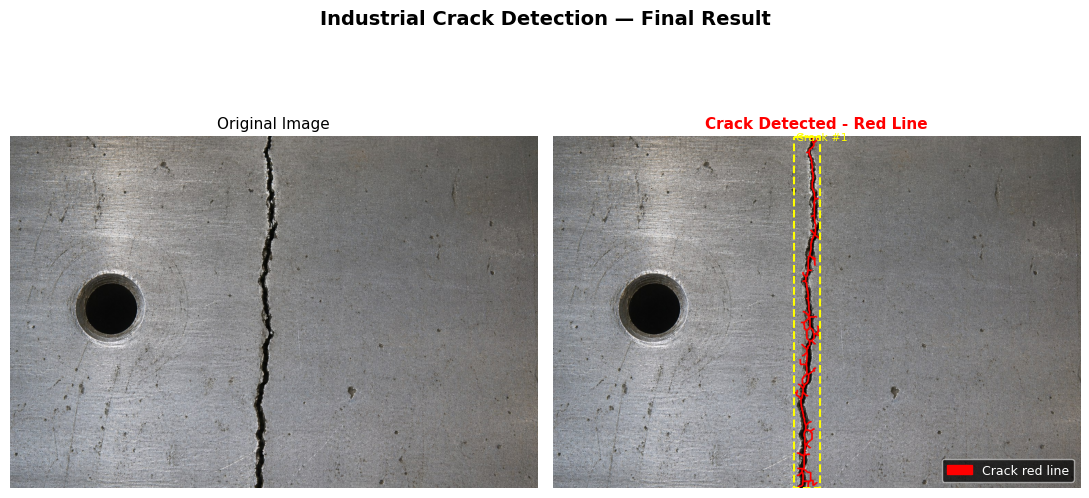

✅ Crack regions found: 1
✅ Total crack line pixels : 9606
✅ Result saved to crack_detection_result.png


In [14]:

# Draw ONLY the crack centerline in red on top of the original image
result = original.copy()
result[crack_line > 0] = [0, 0, 255]   # BGR red

# Find connected crack lines for annotation
labels_final = measure.label(crack_skeleton > 0)
regions_final = [region for region in measure.regionprops(labels_final) if region.area > 10]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
fig.suptitle('Industrial Crack Detection — Final Result', fontsize=14, fontweight='bold', y=1.02)

# Left: original
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontsize=11)
axes[0].axis('off')

# Right: original + red crack line only
axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title('Crack Detected - Red Line', fontsize=11, color='red', fontweight='bold')
axes[1].axis('off')

# Draw bounding box around each crack line region
for i, region in enumerate(regions_final, 1):
    minr, minc, maxr, maxc = region.bbox
    rect = plt.Rectangle(
        (minc, minr), maxc - minc, maxr - minr,
        linewidth=1.5, edgecolor='yellow', facecolor='none', linestyle='--'
    )
    axes[1].add_patch(rect)
    axes[1].annotate(
        f'Crack #{i}',
        xy=(minc, minr), xytext=(minc + 5, max(minr - 10, 10)),
        fontsize=8, color='yellow',
        arrowprops=dict(arrowstyle='->', color='yellow', lw=1)
    )

# Legend
crack_patch = mpatches.Patch(color='red', label='Crack red line')
axes[1].legend(handles=[crack_patch], loc='lower right', fontsize=9,
               facecolor='black', labelcolor='white', framealpha=0.7)

plt.tight_layout()
plt.savefig('crack_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Crack regions found: {len(regions_final)}')
print(f'✅ Total crack line pixels : {crack_pixel_count}')
print('✅ Result saved to crack_detection_result.png')


## Full 8-Panel Pipeline Summary

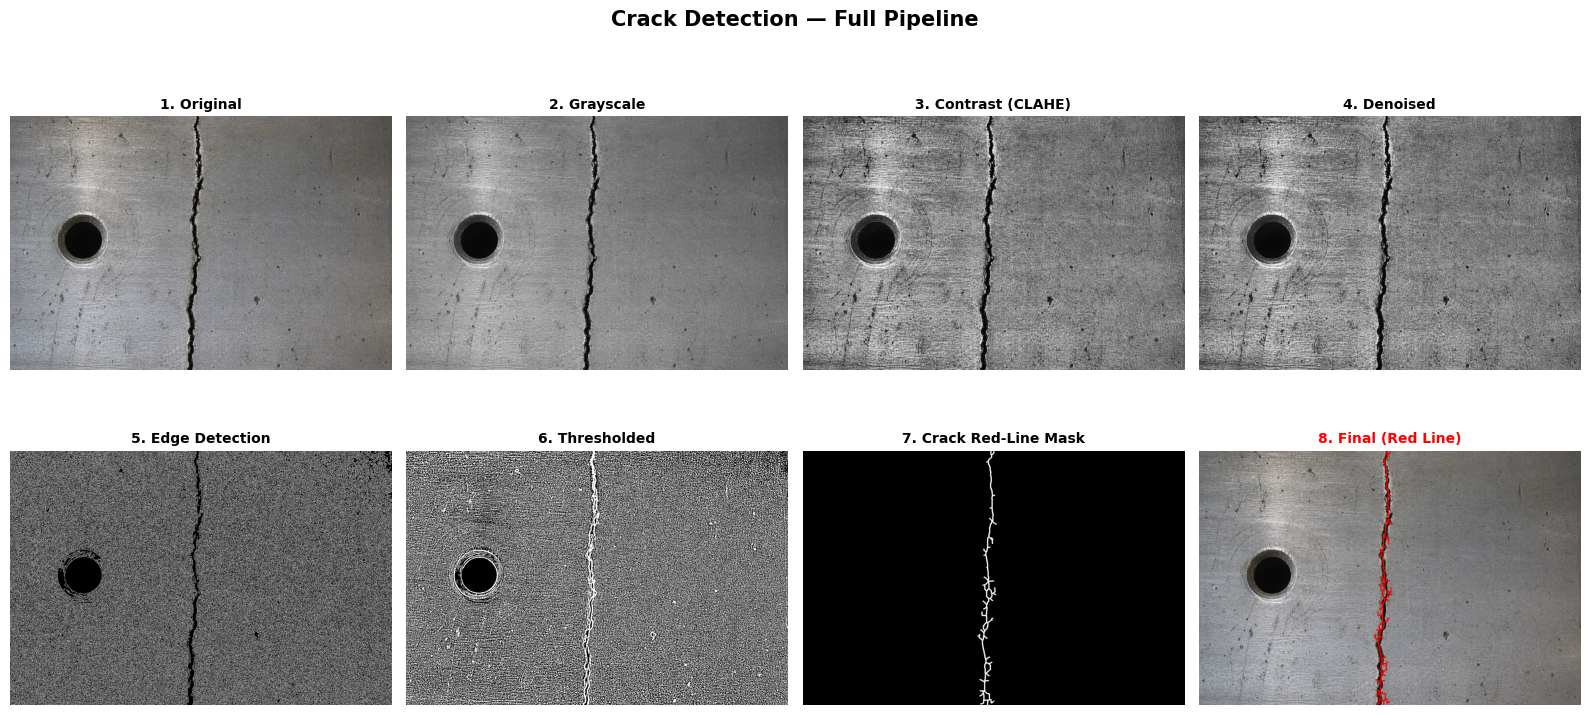

✅ Pipeline summary saved to crack_detection_pipeline.png


In [15]:

panels = [
    (cv2.cvtColor(original, cv2.COLOR_BGR2RGB), '1. Original',             'gray'),
    (gray,                                       '2. Grayscale',            'gray'),
    (contrast,                                   '3. Contrast (CLAHE)',     'gray'),
    (denoised,                                   '4. Denoised',             'gray'),
    (edges,                                      '5. Edge Detection',       'gray'),
    (thresh,                                     '6. Thresholded',          'gray'),
    (crack_line,                                 '7. Crack Red-Line Mask',  'gray'),
    (cv2.cvtColor(result, cv2.COLOR_BGR2RGB),    '8. Final (Red Line)',     None),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Crack Detection — Full Pipeline', fontsize=15, fontweight='bold')

for ax, (img, title, cmap) in zip(axes.flat, panels):
    ax.imshow(img, cmap=cmap)
    color = 'red' if '8.' in title else 'black'
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('crack_detection_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Pipeline summary saved to crack_detection_pipeline.png')


## ⚙️ Tuning Parameters

| Parameter | Location | Effect |
|-----------|----------|--------|
| `clipLimit` (CLAHE) | Step 3 | Higher → more contrast, more noise |
| `h` (denoising) | Step 4 | Higher → smoother, may lose fine cracks |
| `threshold1/2` (Canny) | Step 5 | Lower → detects faint cracks |
| `blockSize` (adaptive thresh) | Step 6 | Larger → less sensitive to lighting |
| `aspect_ratio > 3.0` | Step 7 | Raise to suppress noisy blobs |
| `solidity < 0.75` | Step 7 | Lower to exclude more compact shapes |
| `min_size=50` | Step 7 | Raise to ignore small crack fragments |